In [1]:
import pandas as pd

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [2]:
nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  object 
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.1+ MB


In [3]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(
    ['amfi_code','date']
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

print("Libraries Loaded")

Libraries Loaded


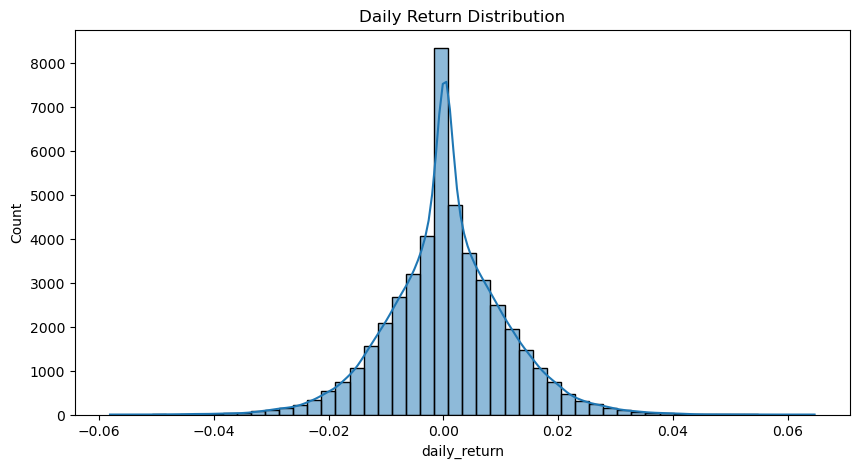

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")

plt.show()

In [9]:
fund_summary = nav.groupby('amfi_code').agg(
    start_nav=('nav','first'),
    end_nav=('nav','last'),
    observations=('nav','count')
)

fund_summary.head()

,start_nav,end_nav,observations
amfi_code,,,
100016,520.4608,583.6113,1150
100025,26.3169,31.8843,1150
100033,107.3758,342.0072,1150
101206,305.0996,773.2939,1150
101207,38.5736,53.9836,1150


In [10]:
fund_summary['years'] = (
    fund_summary['observations'] / 252
)

fund_summary['cagr_pct'] = (
    (
        fund_summary['end_nav']
        /
        fund_summary['start_nav']
    )
    **
    (
        1 / fund_summary['years']
    )
    - 1
) * 100

fund_summary[['cagr_pct']].head()

,cagr_pct
amfi_code,
100016,2.541248
100025,4.294835
100033,28.899384
101206,22.604787
101207,7.643258


In [11]:
risk_free_rate = 0.065

sharpe = nav.groupby('amfi_code')['daily_return'].agg(
    mean_return='mean',
    std_return='std'
)

sharpe['sharpe_ratio'] = (
    (
        sharpe['mean_return'] * 252
        - risk_free_rate
    )
    /
    (
        sharpe['std_return']
        * np.sqrt(252)
    )
)

sharpe.head()

,mean_return,std_return,sharpe_ratio
amfi_code,,,
100016,0.000142,0.009164,-0.201517
100025,0.000170,0.002460,-0.567095
100033,0.001080,0.011929,1.093699
101206,0.000852,0.009177,1.027213
101207,0.000424,0.016251,0.162661


In [12]:
fund_summary = fund_summary.merge(
    sharpe[['sharpe_ratio']],
    left_index=True,
    right_index=True
)

fund_summary.head()

,start_nav,end_nav,observations,years,cagr_pct,sharpe_ratio
amfi_code,,,,,,
100016,520.4608,583.6113,1150,4.563492,2.541248,-0.201517
100025,26.3169,31.8843,1150,4.563492,4.294835,-0.567095
100033,107.3758,342.0072,1150,4.563492,28.899384,1.093699
101206,305.0996,773.2939,1150,4.563492,22.604787,1.027213
101207,38.5736,53.9836,1150,4.563492,7.643258,0.162661


In [13]:
top_sharpe = fund_summary.sort_values(
    'sharpe_ratio',
    ascending=False
).head(10)

top_sharpe

,start_nav,end_nav,observations,years,cagr_pct,sharpe_ratio
amfi_code,,,,,,
148567,70.2514,230.2708,1150,4.563492,29.711990,1.448291
120843,49.9131,163.2397,1150,4.563492,29.648348,1.306744
148569,28.8620,97.7435,1150,4.563492,30.643215,1.234930
119551,54.3856,149.3216,1150,4.563492,24.772562,1.208267
120505,135.8720,473.7640,1150,4.563492,31.481115,1.180101
149323,78.4622,245.3651,1150,4.563492,28.381646,1.132122
100033,107.3758,342.0072,1150,4.563492,28.899384,1.093699
118632,42.8339,110.5554,1150,4.563492,23.093816,1.081659
101206,305.0996,773.2939,1150,4.563492,22.604787,1.027213


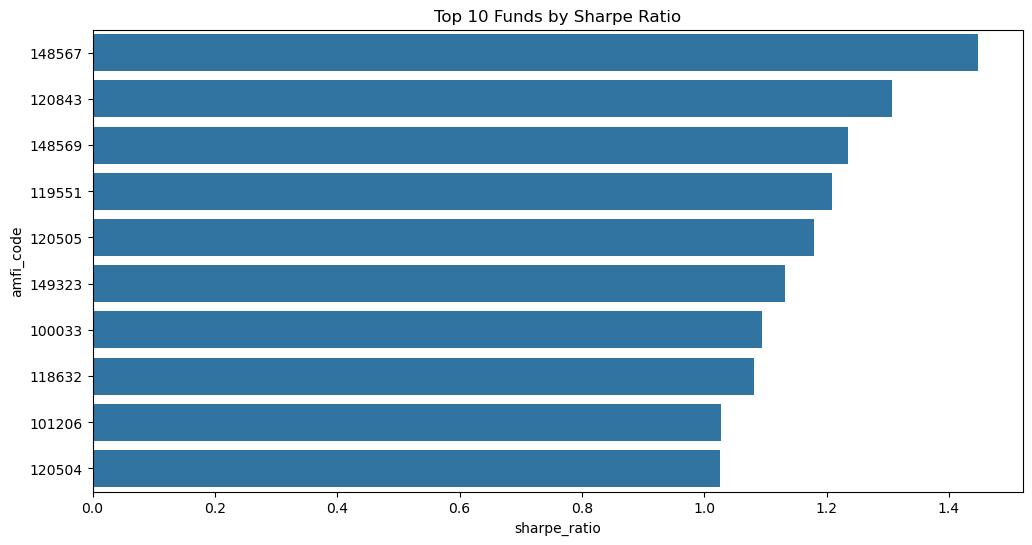

In [14]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_sharpe['sharpe_ratio'],
    y=top_sharpe.index.astype(str)
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.show()

In [15]:
fund_summary.head()


,start_nav,end_nav,observations,years,cagr_pct,sharpe_ratio
amfi_code,,,,,,
100016,520.4608,583.6113,1150,4.563492,2.541248,-0.201517
100025,26.3169,31.8843,1150,4.563492,4.294835,-0.567095
100033,107.3758,342.0072,1150,4.563492,28.899384,1.093699
101206,305.0996,773.2939,1150,4.563492,22.604787,1.027213
101207,38.5736,53.9836,1150,4.563492,7.643258,0.162661


In [16]:
def calculate_max_drawdown(group):
    
    running_max = group['nav'].cummax()
    
    drawdown = (
        group['nav'] / running_max
    ) - 1
    
    return drawdown.min() * 100


max_dd = (
    nav.groupby('amfi_code')
       .apply(calculate_max_drawdown)
       .to_frame('max_drawdown_pct')
)

max_dd.head()

C:\Users\jaganpalaparthi\AppData\Local\Temp\ipykernel_11888\911822871.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_max_drawdown)


,max_drawdown_pct
amfi_code,
100016,-24.734441
100025,-4.308264
100033,-16.217209
101206,-11.291596
101207,-35.446916


In [17]:
fund_summary = fund_summary.merge(
    max_dd,
    left_index=True,
    right_index=True
)

fund_summary.head()

,start_nav,end_nav,observations,years,cagr_pct,sharpe_ratio,max_drawdown_pct
amfi_code,,,,,,,
100016,520.4608,583.6113,1150,4.563492,2.541248,-0.201517,-24.734441
100025,26.3169,31.8843,1150,4.563492,4.294835,-0.567095,-4.308264
100033,107.3758,342.0072,1150,4.563492,28.899384,1.093699,-16.217209
101206,305.0996,773.2939,1150,4.563492,22.604787,1.027213,-11.291596
101207,38.5736,53.9836,1150,4.563492,7.643258,0.162661,-35.446916


In [18]:
def calculate_sortino(group):
    
    returns = group['daily_return'].dropna()
    
    downside = returns[
        returns < 0
    ]
    
    if len(downside) == 0:
        return np.nan
    
    downside_std = (
        downside.std()
        * np.sqrt(252)
    )
    
    annual_return = (
        returns.mean()
        * 252
    )
    
    return (
        annual_return - 0.065
    ) / downside_std


sortino = (
    nav.groupby('amfi_code')
       .apply(calculate_sortino)
       .to_frame('sortino_ratio')
)

sortino.head()

C:\Users\jaganpalaparthi\AppData\Local\Temp\ipykernel_11888\3942314707.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_sortino)


,sortino_ratio
amfi_code,
100016,-0.351047
100025,-0.941821
100033,1.829134
101206,1.799563
101207,0.276644


In [19]:
fund_summary = fund_summary.merge(
    sortino,
    left_index=True,
    right_index=True
)

fund_summary.head()

,start_nav,end_nav,observations,years,cagr_pct,sharpe_ratio,max_drawdown_pct,sortino_ratio
amfi_code,,,,,,,,
100016,520.4608,583.6113,1150,4.563492,2.541248,-0.201517,-24.734441,-0.351047
100025,26.3169,31.8843,1150,4.563492,4.294835,-0.567095,-4.308264,-0.941821
100033,107.3758,342.0072,1150,4.563492,28.899384,1.093699,-16.217209,1.829134
101206,305.0996,773.2939,1150,4.563492,22.604787,1.027213,-11.291596,1.799563
101207,38.5736,53.9836,1150,4.563492,7.643258,0.162661,-35.446916,0.276644


In [20]:
fund_summary['return_rank'] = (
    fund_summary['cagr_pct']
    .rank(ascending=False)
)

fund_summary['sharpe_rank'] = (
    fund_summary['sharpe_ratio']
    .rank(ascending=False)
)

fund_summary['drawdown_rank'] = (
    fund_summary['max_drawdown_pct']
    .rank(ascending=False)
)

fund_summary['fund_score'] = (
    (
        fund_summary['return_rank']
        * 0.5
    )
    +
    (
        fund_summary['sharpe_rank']
        * 0.3
    )
    +
    (
        fund_summary['drawdown_rank']
        * 0.2
    )
)

fund_summary.head()

,start_nav,end_nav,observations,years,cagr_pct,sharpe_ratio,max_drawdown_pct,sortino_ratio,return_rank,sharpe_rank,drawdown_rank,fund_score
amfi_code,,,,,,,,,,,,
100016,520.4608,583.6113,1150,4.563492,2.541248,-0.201517,-24.734441,-0.351047,37.0,35.0,34.0,35.8
100025,26.3169,31.8843,1150,4.563492,4.294835,-0.567095,-4.308264,-0.941821,36.0,39.0,4.0,30.5
100033,107.3758,342.0072,1150,4.563492,28.899384,1.093699,-16.217209,1.829134,7.0,7.0,20.0,9.6
101206,305.0996,773.2939,1150,4.563492,22.604787,1.027213,-11.291596,1.799563,12.0,9.0,9.0,10.5
101207,38.5736,53.9836,1150,4.563492,7.643258,0.162661,-35.446916,0.276644,27.0,28.0,38.0,29.5


In [21]:
top_funds = (
    fund_summary
    .sort_values(
        'fund_score'
    )
    .head(10)
)

top_funds

,start_nav,end_nav,observations,years,cagr_pct,sharpe_ratio,max_drawdown_pct,sortino_ratio,return_rank,sharpe_rank,drawdown_rank,fund_score
amfi_code,,,,,,,,,,,,
148567,70.2514,230.2708,1150,4.563492,29.711990,1.448291,-11.265729,2.385644,5.0,1.0,8.0,4.4
120843,49.9131,163.2397,1150,4.563492,29.648348,1.306744,-12.973968,2.364320,6.0,2.0,13.0,6.2
120505,135.8720,473.7640,1150,4.563492,31.481115,1.180101,-18.188514,2.029353,1.0,5.0,25.0,7.0
148569,28.8620,97.7435,1150,4.563492,30.643215,1.234930,-16.396743,2.146914,4.0,3.0,21.0,7.1
100033,107.3758,342.0072,1150,4.563492,28.899384,1.093699,-16.217209,1.829134,7.0,7.0,20.0,9.6
119551,54.3856,149.3216,1150,4.563492,24.772562,1.208267,-15.012385,2.140267,10.0,4.0,17.0,9.6
149323,78.4622,245.3651,1150,4.563492,28.381646,1.132122,-17.248106,1.875101,8.0,6.0,22.0,10.2
101206,305.0996,773.2939,1150,4.563492,22.604787,1.027213,-11.291596,1.799563,12.0,9.0,9.0,10.5
120504,60.1474,151.1311,1150,4.563492,22.372038,1.026524,-12.588276,1.805294,13.0,10.0,12.0,11.9


In [22]:
fund_summary.to_csv(
    "../reports/fund_scorecard.csv"
)

print("Fund Scorecard Saved")

Fund Scorecard Saved


In [24]:
import pandas as pd

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [25]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [26]:
benchmark['index_name'].unique()

array(['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP',
       'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT'], dtype=object)

In [27]:
benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100 = nifty100.sort_values(
    'date'
)

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [28]:
from scipy.stats import linregress

results = []

for fund in nav['amfi_code'].unique():

    fund_data = nav[
        nav['amfi_code'] == fund
    ][['date','daily_return']]

    merged = pd.merge(
        fund_data,
        nifty100[['date','benchmark_return']],
        on='date',
        how='inner'
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r, p, std = linregress(
        merged['benchmark_return'],
        merged['daily_return']
    )

    beta = slope

    alpha = intercept * 252

    results.append([
        fund,
        alpha,
        beta
    ])

alpha_beta = pd.DataFrame(
    results,
    columns=[
        'amfi_code',
        'alpha',
        'beta'
    ]
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [29]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Alpha Beta Saved")

Alpha Beta Saved


In [30]:
fund_summary = fund_summary.merge(
    alpha_beta,
    left_index=True,
    right_on='amfi_code',
    how='left'
)

fund_summary.head()

,start_nav,end_nav,observations,years,cagr_pct,sharpe_ratio,max_drawdown_pct,sortino_ratio,return_rank,sharpe_rank,drawdown_rank,fund_score,amfi_code,alpha,beta
0,520.4608,583.6113,1150,4.563492,2.541248,-0.201517,-24.734441,-0.351047,37.0,35.0,34.0,35.8,100016,0.037476,-0.058268
1,26.3169,31.8843,1150,4.563492,4.294835,-0.567095,-4.308264,-0.941821,36.0,39.0,4.0,30.5,100025,0.042818,0.001158
2,107.3758,342.0072,1150,4.563492,28.899384,1.093699,-16.217209,1.829134,7.0,7.0,20.0,9.6,100033,0.271954,0.005104
3,305.0996,773.2939,1150,4.563492,22.604787,1.027213,-11.291596,1.799563,12.0,9.0,9.0,10.5,101206,0.213998,0.021086
4,38.5736,53.9836,1150,4.563492,7.643258,0.162661,-35.446916,0.276644,27.0,28.0,38.0,29.5,101207,0.108971,-0.065289


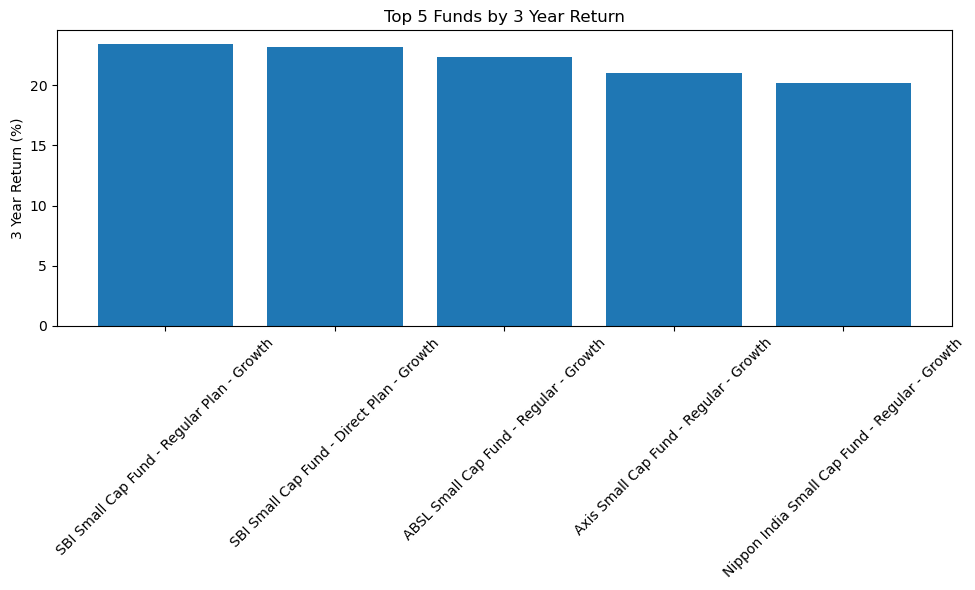

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

top5 = performance.sort_values(
    "return_3yr_pct",
    ascending=False
).head(5)

plt.figure(figsize=(10,6))

plt.bar(
    top5["scheme_name"],
    top5["return_3yr_pct"]
)

plt.xticks(rotation=45)
plt.ylabel("3 Year Return (%)")
plt.title("Top 5 Funds by 3 Year Return")

plt.tight_layout()

plt.savefig(
    "../reports/charts/benchmark_comparison.png"
)

plt.show()

Did alpha_beta.csv get created successfully?